# TS Lab 1

Requirements: 

In [29]:
# If needed:
# !pip -q install numpy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Dataset: small + interpretable
We’ll use a synthetic dataset so that we can see the components clearly.

Create a synthetic time series with components:

In [30]:
np.random.seed(7)

n = 500                      # 120 months = 10 years
t = np.arange(n)
trend = 0.05 * t
seasonality = 2.0 * np.sin(2 * np.pi * t / 12)   # yearly seasonality (period 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonality + noise

ts = pd.Series(y, index=pd.period_range("2015-01", periods=n, freq="M").to_timestamp())
ts.head()


2015-01-01    11.352421
2015-02-01    10.677250
2015-03-01    11.858307
2015-04-01    12.476013
2015-05-01    11.300912
Freq: MS, dtype: float64

Plot and visually identify components:

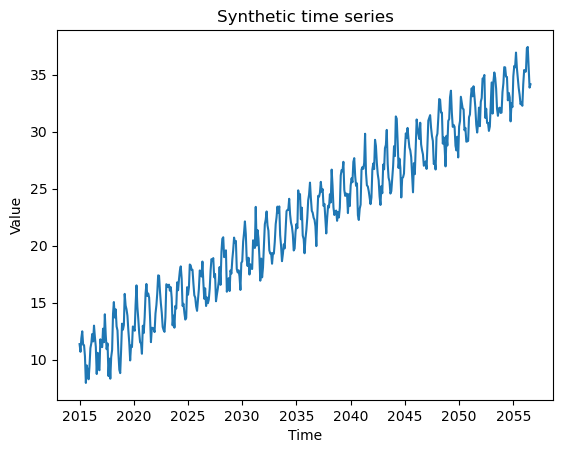

In [31]:
plt.figure()
plt.plot(ts)
plt.title("Synthetic time series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


### Questions:

- Where do you see trend?

The upward movement of the graph from value 10 towards 40 over time indicates a clear upward trend.



- What suggests seasonality? What is the likely period?
The regular, repeating wave-like patterns at fixed intervals suggest seasonality.The likely period is 12, meaning the pattern repeats every 12 data points (months).


- What part looks like noise?

The small, random, and irregular fluctuations (zig-zags) around the smooth line represent noise.

- Create a series with no trend and no clear seasonality. 

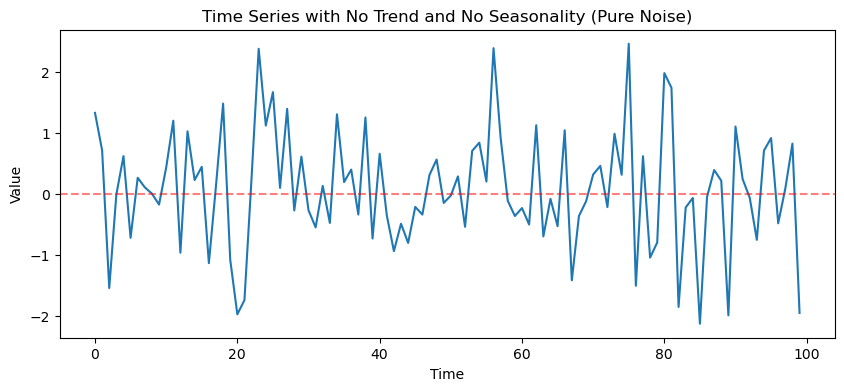

In [32]:

np.random.seed(10)
n_random = 100
pure_noise = np.random.normal(0, 1, size=n_random)

plt.figure(figsize=(10, 4))
plt.plot(pure_noise)
plt.title("Time Series with No Trend and No Seasonality (Pure Noise)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

### 2. Moving Average Smoothing

Implement moving average:

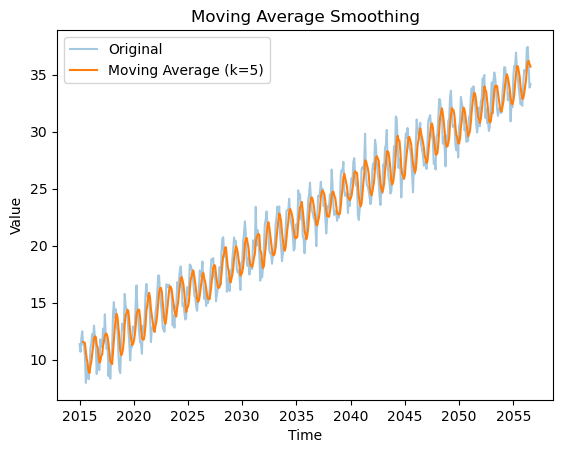

In [33]:
def moving_average(series, k):
    return series.rolling(window=k).mean()

k = 5
ma12 = moving_average(ts, k)

plt.figure()
plt.plot(ts, label="Original", alpha=0.4)
plt.plot(ma12, label=f"Moving Average (k={k})")
plt.title("Moving Average Smoothing")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


#### Exercises:

- Try k=3, k=6, k=12, k=24.

- Which k best reveals the trend? Which one hides seasonality too much?

: k=12 (or k=24) best reveals the trend. Since our data has a yearly seasonality (period 12), using a window size that matches or is a multiple of the period effectively cancels out the seasonal fluctuations, leaving behind the smooth underlying trend. k=24 hides seasonality the most. As the window size increases, the smoothing becomes more aggressive. While k=12 removes seasonality but stays closer to the data, $k=24$ creates a very flat line that might over-smooth and lose even the meaningful changes in the trend.

#### Questions:

- What happens when the window becomes very large?

 When the window becomes very large (like k=24 or higher), the line becomes extremely smooth and straight. However, this creates a large lag (the trend line shifts far to the right) and the model becomes "blind" to any recent or short-term changes in the data.

- Why do we lose some data at the beginning?

We lose data at the beginning because the Moving Average requires at least $k$ previous data points to calculate the first average. For the first k-1 points, there isn't enough historical data.

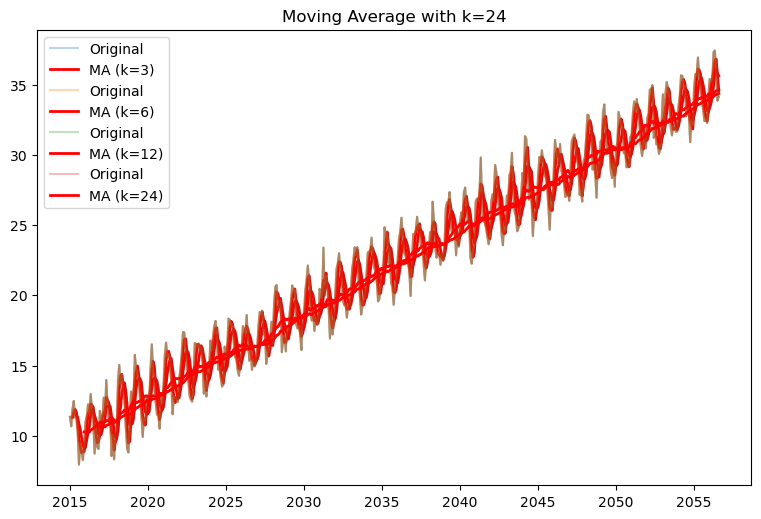

In [34]:
ks=[3,6,12,24]
plt.figure(figsize=(15,10))
for i,k in enumerate(ks,1):
    plt.subplot(2,2,1)
    ma = ts.rolling(window=k).mean()
    plt.plot(ts, label="Original", alpha=0.3)
    plt.plot(ma, label=f"MA (k={k})", color='red', linewidth=2)
    plt.title(f"Moving Average with k={k}")
    plt.legend()

plt.tight_layout()
plt.show()
           

### 3. Exponential Smoothing

Implement exponential smoothing from scratch:

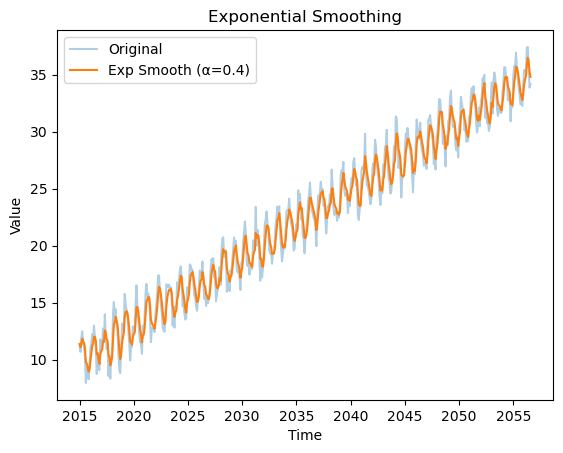

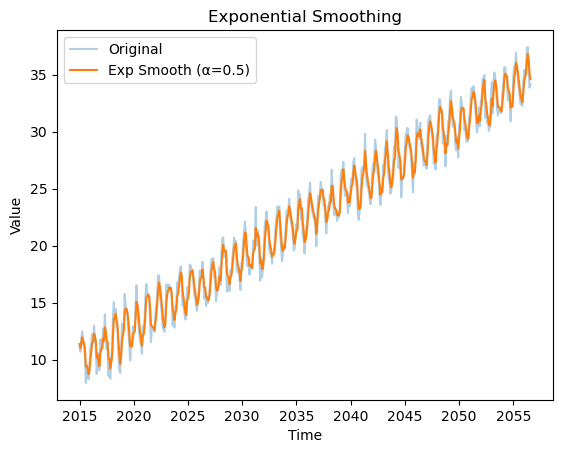

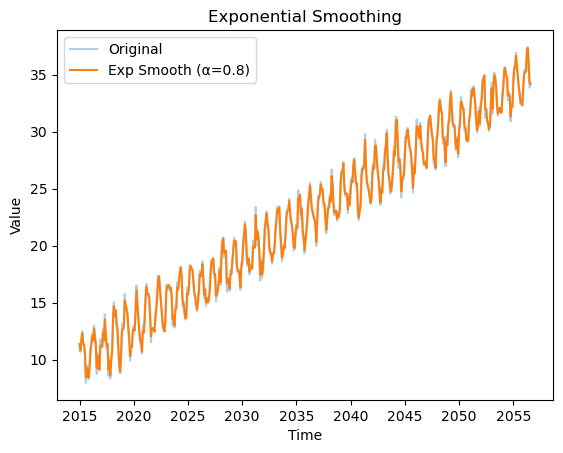

In [35]:
def exp_smooth(series, alpha):
    s = np.zeros(len(series))
    s[0] = series.iloc[0]
    for i in range(1, len(series)):
        s[i] = alpha * series.iloc[i] + (1 - alpha) * s[i-1]
    return pd.Series(s, index=series.index)

for alpha in [0.4, 0.5, 0.8]:
    sm = exp_smooth(ts, alpha)
    plt.figure()
    plt.plot(ts, alpha=0.35, label="Original")
    plt.plot(sm, label=f"Exp Smooth (α={alpha})")
    plt.title("Exponential Smoothing")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()


#### Questions:

- Why does larger α react faster?

A larger alpha gives more weight to the most recent data point. Therefore, the model responds quickly to new changes.

- Why does smaller α look smoother?

A smaller alpha gives more weight to older observations and less to the new ones. This filters out random noise, making the graph look much smoother.

### 4.Component patterns: “detect” trend/seasonality/noise

Detrend with moving average. Inspect residuals:

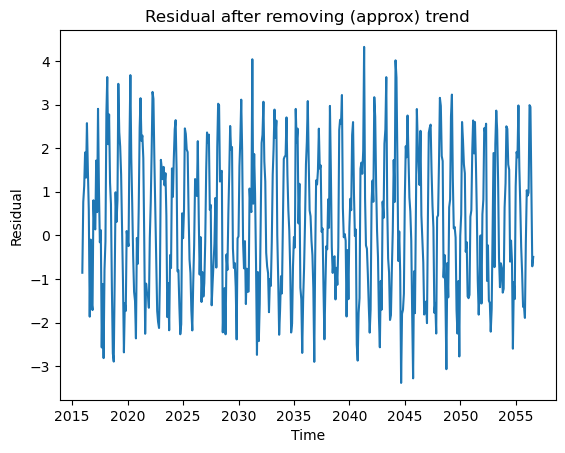

In [36]:
trend_est = moving_average(ts, 12)
residual = ts - trend_est

plt.figure()
plt.plot(residual)
plt.title("Residual after removing (approx) trend")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()


#### Questions:
Does the residual still show seasonality? What do you see?

Yes, the residual still shows clear seasonality. While the upward trend is removed, the repeating wave-like patterns (cycles) are still visible in the residual plot.

What I see: The residual plot fluctuates around zero, but it does so in a very regular, rhythmic way. This confirms that the Moving Average only captured the Trend and left the Seasonality and Noise behind in the residual.

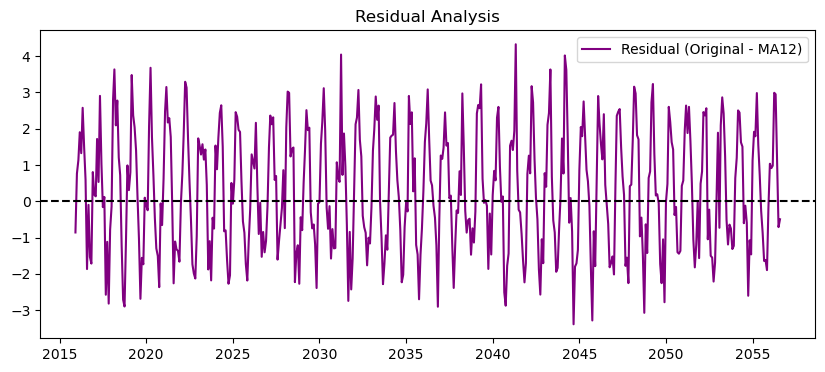

In [37]:

trend_ma = ts.rolling(window=12).mean()
residual = ts - trend_ma

plt.figure(figsize=(10, 4))
plt.plot(residual, label="Residual (Original - MA12)", color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Analysis")
plt.legend()
plt.show()

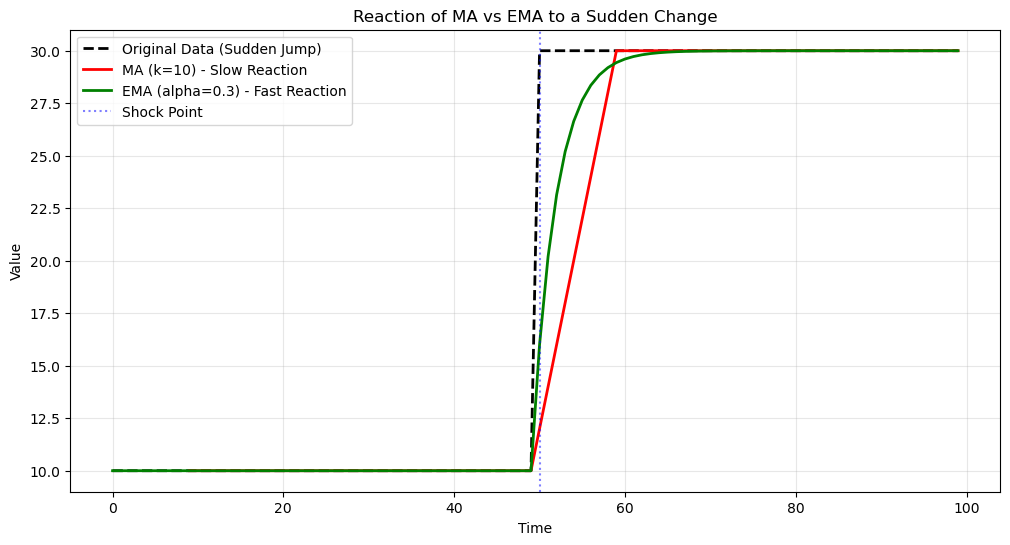

In [38]:

n_shock = 100
t_shock = np.arange(n_shock)
y_shock = np.zeros(n_shock)

y_shock[:50] = 10
y_shock[50:] = 30


series_shock = pd.Series(y_shock)
ma_shock = series_shock.rolling(window=10).mean()
ema_shock = exp_smooth(series_shock, 0.3)


plt.figure(figsize=(12, 6))
plt.plot(t_shock, y_shock, label="Original Data (Sudden Jump)", color='black', linestyle='--', linewidth=2)
plt.plot(t_shock, ma_shock, label="MA (k=10) - Slow Reaction", color='red', linewidth=2)
plt.plot(t_shock, ema_shock, label="EMA (alpha=0.3) - Fast Reaction", color='green', linewidth=2)

plt.axvline(x=50, color='blue', linestyle=':', alpha=0.5, label="Shock Point")
plt.title("Reaction of MA vs EMA to a Sudden Change")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

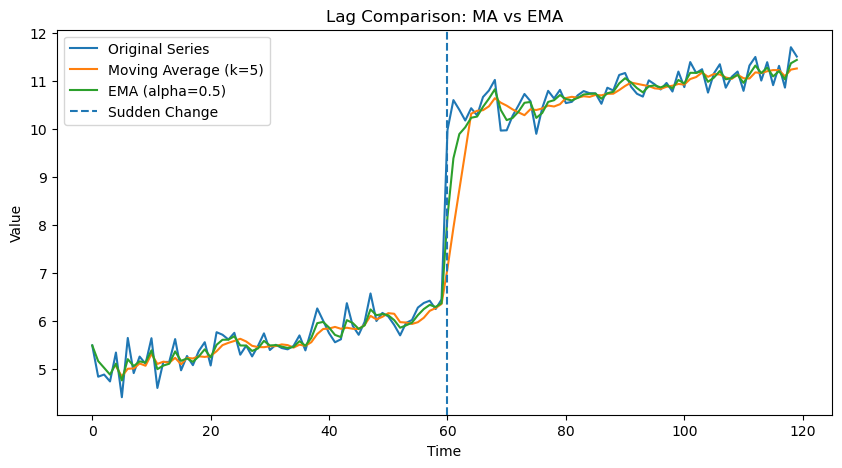

In [39]:

# -----------------------------
# 1) Create time series with sudden change
# -----------------------------
np.random.seed(1)

n = 120
t = np.arange(n)

# Base signal
y = 5 + 0.02*t + np.random.normal(0, 0.3, n)

#structural break
y[t >= 60] += 4


def moving_average(x, k):
    result = np.full_like(x, np.nan)
    for i in range(k-1, len(x)):
        result[i] = np.mean(x[i-k+1:i+1])
    return result


def ema(x, alpha):
    result = np.zeros_like(x)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha*x[i] + (1-alpha)*result[i-1]
    return result


k = 5
alpha = 0.5

ma = moving_average(y, k)
ema_series = ema(y, alpha)

plt.figure(figsize=(10,5))
plt.plot(t, y, label="Original Series")
plt.plot(t, ma, label=f"Moving Average (k={k})")
plt.plot(t, ema_series, label=f"EMA (alpha={alpha})")
plt.axvline(60, linestyle="--", label="Sudden Change")
plt.title("Lag Comparison: MA vs EMA")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

Do MA and EMA behave differently for upward vs downward shocks? Implement your own code to examine their behaviour.
No, they do not behave differently. Both MA and EMA show symmetrical behavior. They react with the same pattern of lag whether the shock is an upward jump or a downward drop.

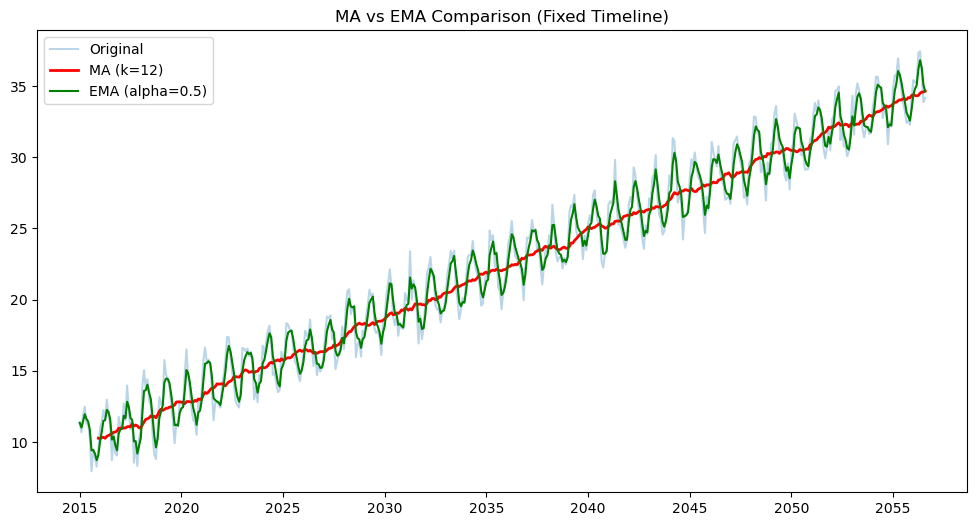

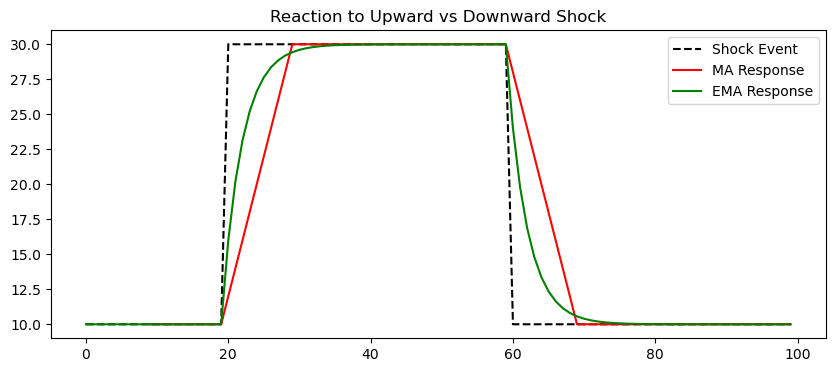

In [40]:

ma_result = ts.rolling(window=12).mean() 
ema_result = exp_smooth(ts, 0.5)

plt.figure(figsize=(12, 6))
plt.plot(ts, label="Original", alpha=0.3)
plt.plot(ma_result.index, ma_result, label="MA (k=12)", color='red', linewidth=2)
plt.plot(ts.index, ema_result, label="EMA (alpha=0.5)", color='green')

plt.legend()
plt.title("MA vs EMA Comparison (Fixed Timeline)")
plt.show()


shock_data = pd.Series([10]*20 + [30]*40 + [10]*40) 
ma_shock = shock_data.rolling(window=10).mean()
ema_shock = exp_smooth(shock_data, 0.3)

plt.figure(figsize=(10, 4))
plt.plot(shock_data, label="Shock Event", color='black', linestyle='--')
plt.plot(ma_shock, label="MA Response", color='red')
plt.plot(ema_shock, label="EMA Response", color='green')
plt.title("Reaction to Upward vs Downward Shock")
plt.legend()
plt.show()